# Figure 4 — Cost ratio vs spectral separation (main result)

**Paper location:** Section 6.2, Fig. 4.

## What this figure shows

The paper's **central organizing result**. The single-spin benchmark fixes `g = 1/2`;
here we vary `g` directly by sweeping the dissipative transverse-field Ising chain over
dissipation strength, interaction strength `J`, and system size `N`. For each instance
we plot the gate-cost ratio `G_QPE / G_Rodeo` at fixed depth against its spectral
separation `g = min_{j≠0,1}|φ_j|`.

Although the points span **three independent microscopic parameters**, they collapse
onto a single trend in `g`: the cost ratio is controlled by the spectral separation
alone, with `N` and `J` entering only through their effect on `g`. The ratio rises
monotonically with `g`, crossing unity near `g ≈ 0.5`, and reaching orders of
magnitude at `g ≳ 1` — **the Rodeo advantage is largest when the steady-state sector
is well separated**.

Crucially, increasing the system size does **not** favour Rodeo at fixed depth: a
larger chain has a *smaller* `g`, hence a *smaller* advantage.

## Model & comparison

| | |
|---|---|
| **Model** | dissipative TFIM, `H = (J/4)ΣZZ + (h/2)ΣX`, `A_j = √γ σ⁻_j`; swept over `γ, J, N` |
| **Compared** | QPE register vs Rodeo van der Corput schedule, at a **fixed** controlled-evolution depth |
| **x-axis** | spectral separation `g` (the smallest nonzero singular value of `L`) |
| **Marker / colour** | marker = system size `N`; colour = interaction `J` |
| **single-spin point** | `g = 1/2` (the Fig. 1 benchmark) sits on the same trend |


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))   # rodeo_ness package
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import rodeo_ness as rn
T, T0 = 15, 0.2
markers = {1:"o", 2:"s", 3:"^", 4:"D"}
Jcol = {0.0:"#0072B2", 1.0:"#D55E00", 2.0:"#009E73"}


### Sweep

In [2]:
# sweep the dissipative TFIM over (N, J, gamma); record g, g_decay, cost ratio
records = []
for N in [1,2,3]:
    for J in [0.0,1.0,2.0]:
        for gamma in np.linspace(0.6,4.0,9):
            L = rn.tfim_liouvillian(N, J=J, h=1.0, gamma=gamma)
            records.append((rn.spectral_separation(L), rn.decay_rate(L),
                            rn.cost_ratio(L, total_depth=T, t0=T0), N, J))
records = np.array(records)
print(f"{len(records)} instances swept")


81 instances swept


### Figure

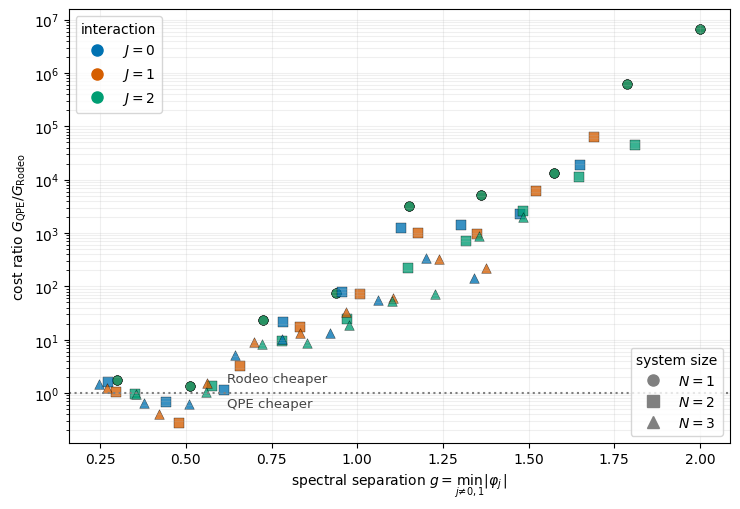

In [3]:
fig,ax=plt.subplots(figsize=(7.5,5.2))
for N in [1,2,3]:
    for J in [0.0,1.0,2.0]:
        m=(records[:,3]==N)&(records[:,4]==J)
        ax.scatter(records[m,0],records[m,2],marker=markers[N],color=Jcol[J],
                   s=48,alpha=0.78,edgecolor="k",linewidth=0.3)
ax.axhline(1.0,ls=":",color="gray",lw=1.5); ax.set_yscale("log")
ax.set_xlabel(r"spectral separation $g=\min_{j\neq0,1}|\varphi_j|$")
ax.set_ylabel(r"cost ratio $G_{\rm QPE}/G_{\rm Rodeo}$")
ax.text(0.62,1.6,"Rodeo cheaper",fontsize=9.5,color="#444")
ax.text(0.62,0.55,"QPE cheaper",fontsize=9.5,color="#444")
ax.grid(alpha=0.2,which="both")
mh=[Line2D([],[],marker=markers[N],color="gray",ls="none",ms=8,label=f"$N={N}$") for N in [1,2,3]]
l1=ax.legend(handles=mh,loc="lower right",title="system size"); ax.add_artist(l1)
ch=[Line2D([],[],marker="o",color=Jcol[J],ls="none",ms=8,label=f"$J={J:.0f}$") for J in [0.0,1.0,2.0]]
ax.legend(handles=ch,loc="upper left",title="interaction")
fig.tight_layout(); fig.savefig("fig_cost_vs_g.pdf",bbox_inches="tight"); plt.show()